# **Performance Evolution: Mean vs. Standard Deviation Shift**

This notebook analyzes the relationship between the shift in average performance (Mean) and the shift in performance spread (Standard Deviation) over time.

### **Quadrants Explained:**
- **Top Right (+Mean, +STD):** Performance improved, but the gap between top and bottom athletes increased (higher diversity).
- **Bottom Right (+Mean, -STD):** Performance improved and the field became more dense/competitive (lower diversity).
- **Top Left (-Mean, +STD):** Performance declined and the field became more spread out.
- **Bottom Left (-Mean, -STD):** Performance declined and the field became more uniform.

In [2]:
import pandas as pd
import numpy as np


from lib import util
from lib import plotting_style as plt
from lib.plotting_style import rgb

# Import local helper functions
import lib.help_functions as hp

In [3]:
# Load the dataset
df = util.load_data()

# Normalize Age Classes
df['altersklasse'] = df['altersklasse'].replace({
    'Maenner': 'Adult', 'Frauen': 'Adult', 
    '16': 'U16', '18': 'U18', 
    '20': 'U20', '14': 'AK14'
})

# Filter for target groups
target_ak = ['Adult', 'U23', 'U20', 'U18']
df = df[df['altersklasse'].isin(target_ak)]

# Group mapping for visualization
mapping_dict = {
    '100 m': 'Sprint', '200 m': 'Sprint', '400 m': 'Sprint', 
    '100 m Huerden': 'Sprint', '110 m Huerden': 'Sprint', '400 m Huerden': 'Sprint',
    '800 m': 'Run', '1500 m': 'Run', '3000 m': 'Run', '5000 m': 'Run', 
    '10 000 m': 'Run', '10 km': 'Run', 'Marathon': 'Run', 
    'Halbmarathon': 'Run', '2000 m Hindernis': 'Run', '3000 m Hindernis': 'Run',
    'Kugelstoss': 'Throw', 'Diskuswurf': 'Throw', 'Speerwurf': 'Throw', 'Hammerwurf': 'Throw', 
    'Hochsprung': 'Jump', 'Stabhochsprung': 'Jump', 'Weitsprung': 'Jump', 'Dreisprung': 'Jump',
    'Zehnkampf': 'Combined', 'Siebenkampf': 'Combined'
}
df['disziplingruppe'] = df['disziplin'].map(mapping_dict)

## **1. Snapshot: 2021-2024 vs. 2001-2004 Baseline**
Analyzing how each discipline has shifted over two decades.

In [4]:
# Calculate statistics per discipline comparing modern era to baseline
stats_discipline = hp.calculate_enhanced_stats(
    df, 
    group_cols=['disziplin'], 
    start_period=(2001, 2004), 
    end_period=(2021, 2024)
    )

# Re-apply group mapping
stats_discipline['Group'] = stats_discipline['disziplin'].map(mapping_dict)
stats_discipline = stats_discipline.dropna(subset=['Group'])
stats_discipline.head()

,disziplin,Mean_Diff_%,P_Val_Mean,Cohen_d,STD_Diff_%,P_Val_STD,Interpretation,Group
0,10 000 m,-4.80,0.0000,-0.255,104.51,0.0000,Small,Run
1,10 km,1.69,0.0004,0.182,46.27,0.0000,Negligible,Run
2,100 m,2.60,0.0000,0.349,21.58,0.0000,Small,Sprint
3,100 m Huerden,0.75,0.0213,0.125,0.49,0.4993,Negligible,Sprint
4,110 m Huerden,-6.83,0.0000,-0.714,63.68,0.0000,Med,Sprint


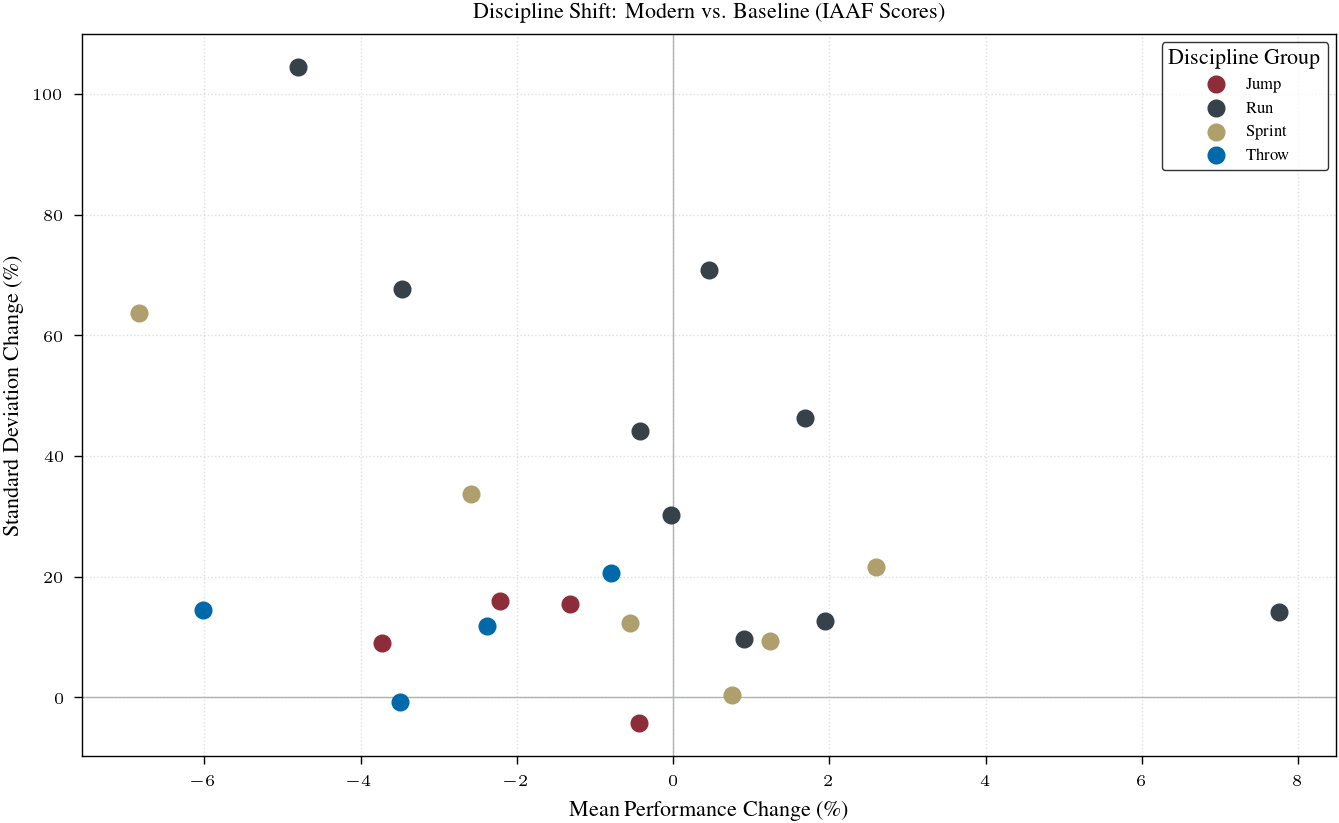

In [6]:
# plt.figure(figsize=(12, 10))

# Define colors for groups
groups = sorted(stats_discipline['Group'].unique())
# with plt.rc_context(plt.increase_figsize(2)):
ax = plt.gca()
# cmap = plt.get_cmap('tab10')

# Manual scatter plot iteration to avoid seaborn
for i, group_name in enumerate(groups):
    mask = stats_discipline['Group'] == group_name
    plt.scatter(
        stats_discipline.loc[mask, 'Mean_Diff_%'], 
        stats_discipline.loc[mask, 'STD_Diff_%'], 
        label=group_name, 
        # color=cmap(i), 
        # s=150, 
        # alpha=0.8, 
        # edgecolors='white', 
        # linewidths=1.2,
        zorder=3
    )

# Reference lines (0,0)
plt.axhline(0, color=rgb.tue_gray,  linewidth=0.5)
plt.axvline(0, color=rgb.tue_gray,  linewidth=0.5)

# Dynamic limits to ensure symmetry
max_val = max(stats_discipline['Mean_Diff_%'].abs().max(), stats_discipline['STD_Diff_%'].abs().max())
lim = max_val * 1.2
# plt.xlim(-lim, lim)
# plt.ylim(-lim, lim)

# Quadrant Labels
# plt.text(lim*0.6, lim*0.8, "Higher Perf.\nMore Spread", ha='center', color='gray', weight='bold')
# plt.text(lim*0.6, -lim*0.8, "Higher Perf.\nMore Uniform", ha='center', color='gray', weight='bold')
# plt.text(-lim*0.6, lim*0.8, "Lower Perf.\nMore Spread", ha='center', color='gray', weight='bold')
# plt.text(-lim*0.6, -lim*0.8, "Lower Perf.\nMore Uniform", ha='center', color='gray', weight='bold')

# Label outliers
# for idx, row in stats_discipline.iterrows():
#     if abs(row['Mean_Diff_%']) > lim*0.3 or abs(row['STD_Diff_%']) > lim*0.3:
#         plt.text(row['Mean_Diff_%'], row['STD_Diff_%']+0.5, row['disziplin'], fontsize=8, alpha=0.7, ha='center')

plt.title('Discipline Shift: Modern vs. Baseline (IAAF Scores)')
plt.xlabel('Mean Performance Change (\\%)')
plt.ylabel('Standard Deviation Change (\\%)')
plt.legend(title="Discipline Group")
plt.grid(True, linestyle=':', alpha=0.4)

plt.show()


## **2. Global Trajectory: 2001 to 2024**
Tracing the evolutionary path of the entire dataset year-by-year.

In [7]:
# Define global baseline (Year 2001)
base_data = df[df['jahr'] == 2001]['iaaf_score']
m0, s0 = base_data.mean(), base_data.std()

traj = []
for year in sorted(df['jahr'].unique()):
    yearly = df[df['jahr'] == year]['iaaf_score']
    m_shift = (yearly.mean() - m0) / m0 * 100
    s_shift = (yearly.std() - s0) / s0 * 100
    traj.append({'Year': year, 'Mean_Shift': m_shift, 'STD_Shift': s_shift})

traj_df = pd.DataFrame(traj)

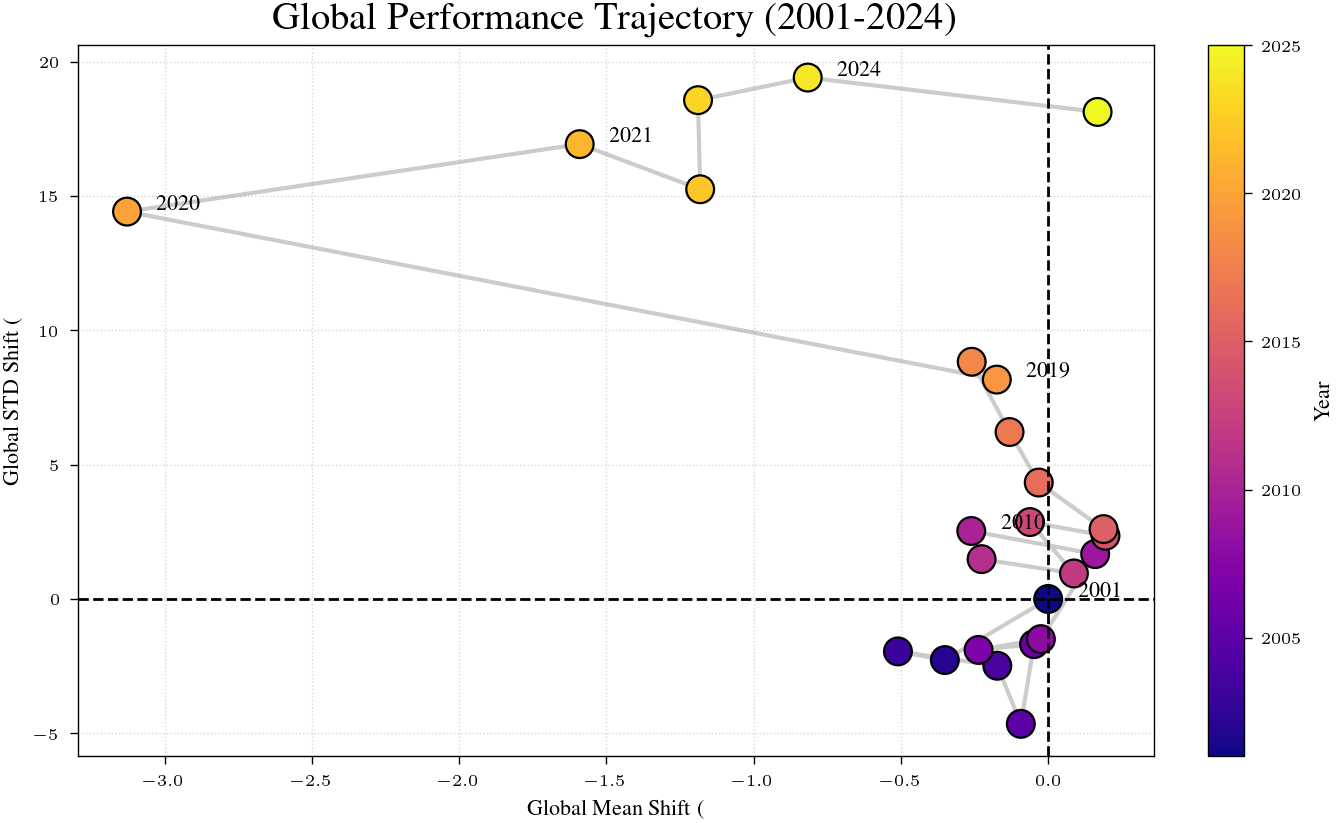

In [9]:


# Plot path line
plt.plot(traj_df['Mean_Shift'], traj_df['STD_Shift'], color='gray', alpha=0.4, linewidth=1.5, zorder=1)

# Scatter with year colormap
sc = plt.scatter(
    traj_df['Mean_Shift'], traj_df['STD_Shift'], 
    c=traj_df['Year'], cmap='plasma', s=100, 
    edgecolor='k', linewidth=0.8, zorder=2
)

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axvline(0, color='black', linewidth=1, linestyle='--')

plt.colorbar(sc, label='Year')

# Label significant years
for _, row in traj_df.iterrows():
    if row['Year'] in [2001, 2010, 2019, 2020, 2021, 2024]:
        plt.text(row['Mean_Shift']+0.1, row['STD_Shift']+0.1, str(int(row['Year'])), fontweight='bold')

plt.title('Global Performance Trajectory (2001-2024)', fontsize=14)
plt.xlabel('Global Mean Shift (%)')
plt.ylabel('Global STD Shift (%)')
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()